# Basic examples of the Observable class

This notebook exemplifies the usage of the Observable class, which stores the data and models of summary statistics used in different projects that the ACM group is working on.

> The Observable class wraps around `xarray`, and therefore allows the use of most of the `xarray` methods to select, slice, and manipulate the data.

The `acm.observables.observable` class provides a unified interface for handling these summary statistics, making it easier to load, manipulate, and visualize the data. 
It loads and combines xarrays DataSets from `.npy` files with the following structure:
- `x`: The DataArray containing the summary statistic parameters.
- `y`: The DataArray containing the summary statistic values.
- `covariance_y`: The DataArray containing the covariance array of the summary statistic.
- `emulator_error`: The DataArray containing the error of the summary statistic emulator.
- `emulator_covariance_y`: The DataArray containing the covariance of the summary statistic emulator.

To load an instance of acm.observables.Observable, you need to provide the path to the directory containing the `.npy` files and specify the name of summary statistic you want to work with. The class will automatically load the relevant files and create the necessary DataArrays.

In [139]:
import numpy as np
import matplotlib.pyplot as plt
import acm.observables.emc as emc
from acm.observables import Observable

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [ ]:
# Each of those paths contains a 'tpcf.npy' file containing an xarray.Dataset object saved as a dict, containing:
paths = {
    'data_dir': '/pscratch/sd/e/epaillas/emc/v1.2/abacus/training_sets/cosmo+hod/', # Loads x, y can also contain covariance_y
    # 'covariance_dir': None, # Loads covariance_y
    # 'error_dir': None, # Loads emulator_error and emulator_covariance_y
    # 'model_dir': None, # Path of the model
    # 'checkpoint_name': None, # Name of the checkpoint to load in model_dir
}

observable = Observable(stat_name='tpcf', paths=paths) # NOTE : A warning is raised as we don't provide a model in the paths, this is expected
observable

'model_dir', model will be undefined. If you are training a new model, this is expected.


## 1- Selecting the data
We have loaded an observable with several dimensions for each variable. Each dimensions can have filters applied on it, that can be given at the instantiation of the class or later on trough the `select_filters` and `slice_filters` class properties.

Let's select only the c000 cosmology, and seperation bins between 0.5 and 50 Mpc/h.

In [130]:
observable.select_filters = {'cosmo_idx': 0} # The name of the coordinates are determined by the user when creating the datasets !
observable.slice_filters = {'s': (0.5, 50)}

observable

We can also use the `xarray` methods directly on the `Observable` instance to manipulate the data. For example, we can use the `sel` method to select specific values along a dimension, or the `isel` method to select values based on their index (as done in the EMC example below)

## 2- Flattening the data
In most of our projects, we need to flatten the data to be able to use it in a likelihood. The `Observable` class provides a `flat_output_dims` parameter that allows you to flatten the data along specified dimensions. This is particularly useful when preparing the data for statistical analysis or machine learning tasks.

`flat_output_dims=1` will flatten the data on all the dimensions, creating a 1D array for each variable.

`flat_output_dims=2` will flatten the data on two dimensions, that must be specified in the attributes of each variable as a dictionary with two keys:
- `sample` is the first dimension, containing the name of all the dimensions that parametrize the sample features (e.g., `cosmo_idx`, `phase`, `seed`, `hod_idx`, etc.)
- `features` is the second dimension, containing the name of all the dimensions that parametrize the summary statistic features (e.g., `s`, `multipoles`, etc.) 

In [131]:
observable.x.attrs

{'sample': ['cosmo_idx', 'hod_idx'], 'features': ['parameters']}

Let's flatten the data on two dimensions: `sample` and `features`.

In [132]:
observable.flat_output_dims = 2
observable.x

<xarray.DataArray 'x' (sample: 100, features: 20)> Size: 16kB
array([[ 0.02237 ,  0.12    ,  0.807952, ..., -0.2957  ,  0.09119 ,
        -0.52551 ],
       [ 0.02237 ,  0.12    ,  0.807952, ..., -0.67385 , -0.54968 ,
        -0.40783 ],
       [ 0.02237 ,  0.12    ,  0.807952, ...,  0.12739 ,  0.18381 ,
         0.02242 ],
       ...,
       [ 0.02237 ,  0.12    ,  0.807952, ...,  0.04841 , -0.30517 ,
         0.7503  ],
       [ 0.02237 ,  0.12    ,  0.807952, ..., -0.20423 , -0.65162 ,
        -0.72175 ],
       [ 0.02237 ,  0.12    ,  0.807952, ...,  0.11281 , -0.55047 ,
         0.1231  ]])
Coordinates:
    cosmo_idx   int64 8B 0
  * sample      (sample) object 800B MultiIndex
  * hod_idx     (sample) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
  * features    (features) object 160B MultiIndex
  * parameters  (features) <U9 720B 'omega_b' 'omega_cdm' ... 'B_cen' 'B_sat'
Attributes:
    sample:    ['cosmo_idx', 'hod_idx']
    features:  ['parameters']

Some retro-compatibility parameters are also added for flattening the data:
- `squeeze_output`: If True, removes all dimensions of size 1 from the data arrays.
- `numpy_output`: If True, converts the data arrays to numpy arrays when accessing the Dataset properties.

> Note: In some instances, combining `flat_output_dims=1`, and `numpy_output` can lead to unexpected behaviors or crashes. It is recommended to use `flat_output_dims=2` for better control over the flattening process.

## 3- Greedy selection of features
In some cases, we want to directly access a subset of the features of the summary statistic, for example to reduce the dimensionality of the data. The `Observable` class provides a `select_indices` parameter that allows you to select a subset of features as an indice selection of the `features` axis. 

> Using `select_indices` and `select_filters` or `slice_filters` at the same time can lead to unexpected behaviors or crashes. Use both only if you are sure of what you are doing.

In [133]:
observable.y[0]

<xarray.DataArray 'y' (features: 39)> Size: 312B
array([ 2.33314818e+01,  6.15406065e+00,  2.54778915e+00,  1.26740701e+00,
        7.17893054e-01,  4.53224452e-01,  3.06272934e-01,  2.16701468e-01,
        1.57060770e-01,  1.17169073e-01,  8.75494922e-02,  6.55987556e-02,
        4.98308901e-02,  5.26099742e+01,  8.74413747e+00,  1.99924798e+00,
        3.79289110e-01, -2.50959782e-02, -1.14044686e-01, -1.23446467e-01,
       -1.07721154e-01, -9.05699053e-02, -7.55004704e-02, -6.27321788e-02,
       -5.50644478e-02, -4.52973996e-02,  6.86469060e+01,  1.25144347e+01,
        3.00220517e+00,  8.22904690e-01,  2.32794766e-01,  7.90661538e-02,
        2.86713179e-02,  1.44967705e-02,  3.93527287e-04,  6.06511568e-04,
        8.04319302e-04, -1.31151120e-03, -7.77765452e-04])
Coordinates:
    cosmo_idx   int64 8B 0
    sample      object 8B (0,)
    hod_idx     int64 8B 0
  * features    (features) object 312B MultiIndex
  * multipoles  (features) int64 312B 0 0 0 0 0 0 0 0 0 0 ... 4 4 4 4 4 4 4 4 4
  * s           (features) float64 312B 2.0 6.0 10.0 14.0 ... 42.0 46.0 50.0
Attributes:
    sample:    ['cosmo_idx', 'hod_idx']
    features:  ['multipoles', 's']

In [134]:
observable.select_indices = [i for i in range(0, int(39/2), 2)] # Selects every second feature
observable.y[0]

Filters applied to features dimensions: ['s']


<xarray.DataArray 'y' (features: 20)> Size: 160B
array([23.33148176,  2.54778915,  0.71789305,  0.30627293,  0.15706077,
        0.08754949,  0.04983089,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,  8.74413747,  0.37928911, -0.11404469])
Coordinates:
    cosmo_idx   int64 8B 0
    sample      object 8B (0,)
    hod_idx     int64 8B 0
  * features    (features) object 160B MultiIndex
  * multipoles  (features) int64 160B 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2
  * s           (features) float64 160B 2.0 10.0 18.0 26.0 ... 6.0 14.0 22.0
Attributes:
    sample:    ['cosmo_idx', 'hod_idx']
    features:  ['multipoles', 's']

In [135]:
y = observable.y[0]
y[~np.isnan(y)] # Remove nan values

Filters applied to features dimensions: ['s']


<xarray.DataArray 'y' (features: 10)> Size: 80B
array([23.33148176,  2.54778915,  0.71789305,  0.30627293,  0.15706077,
        0.08754949,  0.04983089,  8.74413747,  0.37928911, -0.11404469])
Coordinates:
    cosmo_idx   int64 8B 0
    sample      object 8B (0,)
    hod_idx     int64 8B 0
  * features    (features) object 80B MultiIndex
  * multipoles  (features) int64 80B 0 0 0 0 0 0 0 2 2 2
  * s           (features) float64 80B 2.0 10.0 18.0 26.0 ... 50.0 6.0 14.0 22.0
Attributes:
    sample:    ['cosmo_idx', 'hod_idx']
    features:  ['multipoles', 's']

As you can see, some nan values are present in the data that we had to remove. This is because we selected only the first 20 separation feature values, but some of them were removed by our slicer on the `s` dimension, causing bugs in the xarray packing/unpacking process.

Let's try again with a clean observable instance:

In [136]:
observable = Observable(stat_name='tpcf', paths=paths) # NOTE : A warning is raised as we don't provide a model in the paths, this is expected
observable.flat_output_dims=2
observable.select_indices = [i for i in range(0, int(39/2), 2)] # Selects every second feature
observable.select_filters = {'cosmo_idx': 0} # The name of the coordinates are determined by the user when creating the datasets !
# observable.slice_filters = {'s': (0.5, 50)}
observable.y[0]

'model_dir', model will be undefined. If you are training a new model, this is expected.


<xarray.DataArray 'y' (features: 10)> Size: 80B
array([2.33314818e+01, 2.54778915e+00, 7.17893054e-01, 3.06272934e-01,
       1.57060770e-01, 8.75494922e-02, 4.98308901e-02, 2.81909750e-02,
       1.80109028e-02, 9.54219657e-03])
Coordinates:
    cosmo_idx   int64 8B 0
    sample      object 8B (0,)
    hod_idx     int64 8B 0
  * features    (features) object 80B MultiIndex
  * multipoles  (features) int64 80B 0 0 0 0 0 0 0 0 0 0
  * s           (features) float64 80B 2.0 10.0 18.0 26.0 ... 58.0 66.0 74.0
Attributes:
    sample:    ['cosmo_idx', 'hod_idx']
    features:  ['multipoles', 's']

## 4- Wrappers
To add methods to specific classes, create mappings for some summary statistics or make the loading of the data easier on some projects, we can create wrapper classes that inherit from the `Observable` class.

In the example below, we load the galaxy correlation function sample from the DESI Emulator Mock Challenge (EMC). We then plot the multipoles that come from a particular cosmological (c000) and HOD (hod030) model.

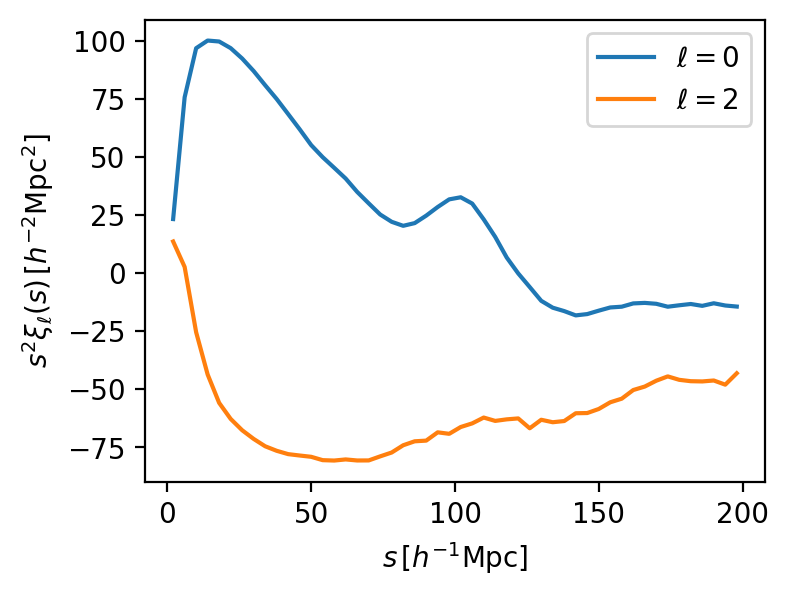

In [ ]:
# xarray class tools
def plot_multipoles(observable):
    """Plot the multipoles of the galaxy correlation function."""
    s = np.array(observable.get_coordinate_list(name='s'))
    fig, ax = plt.subplots(figsize=(4, 3))
    for ell in [0, 2]:
        y = observable.y.sel(cosmo_idx=0, hod_idx=30, multipoles=ell)
        ax.plot(s, s ** 2 * y, label=f'$\ell={ell}$')
    ax.legend()
    ax.set_xlabel(r'$s\,[h^{-1}{\rm Mpc}]$')
    ax.set_ylabel(r'$s^2 \xi_\ell(s)\, [h^{-2}{\rm Mpc}^2]$')
    plt.show()


paths = {
    'data_dir': '/pscratch/sd/e/epaillas/emc/v1.2/abacus/training_sets/cosmo+hod/',
}

observable = emc.GalaxyCorrelationFunctionMultipoles(
    paths=paths,
)

plot_multipoles(observable)

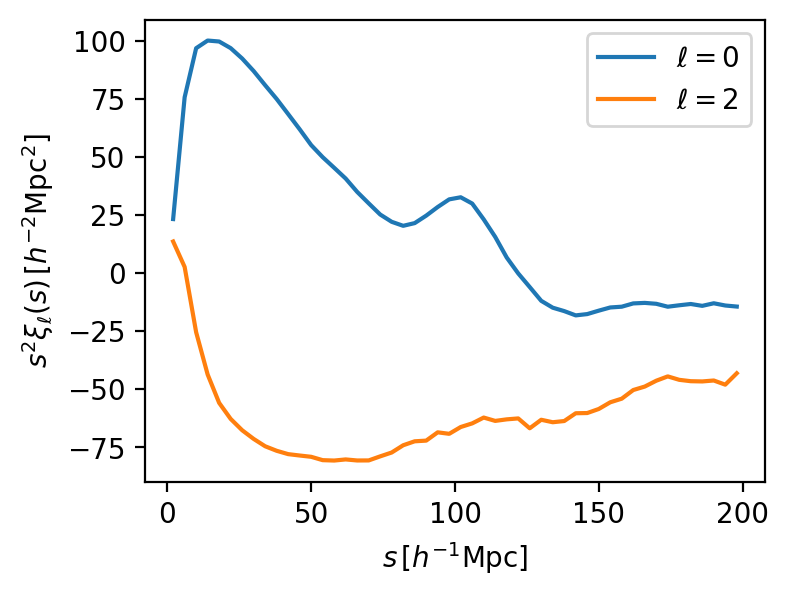

In [ ]:
# Observable class tools

def plot_multipoles(observable):
    """Plot the multipoles of the galaxy correlation function."""
    s = observable.s
    fig, ax = plt.subplots(figsize=(4, 3))
    for i, ell in enumerate([0, 2]):
        y = observable.y[i]
        ax.plot(s, s ** 2 * y, label=f'$\ell={ell}$')
    ax.legend()
    ax.set_xlabel(r'$s\,[h^{-1}{\rm Mpc}]$')
    ax.set_ylabel(r'$s^2 \xi_\ell(s)\, [h^{-2}{\rm Mpc}^2]$')
    plt.show()


paths = {
    'data_dir': '/pscratch/sd/e/epaillas/emc/v1.2/abacus/training_sets/cosmo+hod/',
}

observable = emc.GalaxyCorrelationFunctionMultipoles(
    paths=paths,
    flat_output_dims=0,  # Un-flatten dimensions to have the multipoles as a separate dimension
    select_filters={'cosmo_idx': 0, 'hod_idx': 30, 'multipoles': [0, 2]}, # Select filters here
)

plot_multipoles(observable)